In [ ]:
# ============================================================
# GROKKING EXPERIMENT — Modular Addition mod 97
# Minimal Publishable Setup
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import time

# ============================================================
# Configuration
# ============================================================

P = 97
TRAIN_FRACTION = 0.4
STEPS = 200_000
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 512
SEEDS = 5
LOG_EVERY = 1000

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# ============================================================
# Dataset
# ============================================================

def generate_modular_addition_data(p=97, train_fraction=0.4, seed=0):
    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split_idx = int(len(pairs) * train_fraction)
    train_pairs = pairs[:split_idx]
    test_pairs = pairs[split_idx:]

    def to_tensor(data):
        x = torch.tensor(data, dtype=torch.long)
        y = (x[:, 0] + x[:, 1]) % p
        return x, y

    return to_tensor(train_pairs), to_tensor(test_pairs)

# ============================================================
# Model
# ============================================================

class ModularMLP(nn.Module):
    def __init__(self, p=97, width=128, depth=4):
        super().__init__()

        self.embed = nn.Embedding(p, width)

        layers = []
        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(nn.GELU())

        self.mlp = nn.Sequential(*layers)
        self.output = nn.Linear(width, p)

    def forward(self, x):
        a = self.embed(x[:, 0])
        b = self.embed(x[:, 1])
        h = a + b
        h = self.mlp(h)
        return self.output(h)

# ============================================================
# Accuracy Function
# ============================================================

def accuracy(logits, targets):
    preds = logits.argmax(dim=-1)
    return (preds == targets).float().mean().item()

# ============================================================
# Training Function (One Seed)
# ============================================================

def train_one_seed(seed):
    print(f"\n==============================")
    print(f"Running Seed {seed}")
    print(f"==============================")

    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_modular_addition_data(
        p=P,
        train_fraction=TRAIN_FRACTION,
        seed=seed
    )

    train_x, train_y = train_x.to(DEVICE), train_y.to(DEVICE)
    test_x, test_y = test_x.to(DEVICE), test_y.to(DEVICE)

    model = ModularMLP(p=P, width=128, depth=4).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    train_dataset = torch.utils.data.TensorDataset(train_x, train_y)
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    train_iter = iter(train_loader)

    T_train_acc = None
    T_test_acc = None

    start_time = time.time()

    for step in range(STEPS):

        try:
            x_batch, y_batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x_batch, y_batch = next(train_iter)

        logits = model(x_batch)
        loss = F.cross_entropy(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Logging
        if step % LOG_EVERY == 0:
            model.eval()
            with torch.no_grad():
                train_logits = model(train_x)
                test_logits = model(test_x)

                train_acc = accuracy(train_logits, train_y)
                test_acc = accuracy(test_logits, test_y)

            print(f"Step {step:6d} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Test Acc: {test_acc:.4f}")

            if train_acc >= 0.99 and T_train_acc is None:
                T_train_acc = step

            if test_acc >= 0.99 and T_test_acc is None:
                T_test_acc = step

            model.train()

    total_time = time.time() - start_time

    grokking_delay = None
    if T_train_acc is not None and T_test_acc is not None:
        grokking_delay = T_test_acc - T_train_acc

    result = {
        "seed": seed,
        "T_train": T_train_acc,
        "T_test": T_test_acc,
        "delay": grokking_delay,
        "time_sec": round(total_time, 2)
    }

    print("\nResult:", result)
    return result

# ============================================================
# Run Experiment
# ============================================================

all_results = []

for seed in range(SEEDS):
    res = train_one_seed(seed)
    all_results.append(res)

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

for r in all_results:
    print(r)


Using device: cpu

Running Seed 0
Step      0 | Train Acc: 0.0141 | Test Acc: 0.0085
Step   1000 | Train Acc: 1.0000 | Test Acc: 0.3932
Step   2000 | Train Acc: 1.0000 | Test Acc: 0.3943
Step   3000 | Train Acc: 1.0000 | Test Acc: 0.3937
Step   4000 | Train Acc: 1.0000 | Test Acc: 0.3937
Step   5000 | Train Acc: 1.0000 | Test Acc: 0.3941
Step   6000 | Train Acc: 1.0000 | Test Acc: 0.3941
Step   7000 | Train Acc: 1.0000 | Test Acc: 0.3948
Step   8000 | Train Acc: 1.0000 | Test Acc: 0.3948
Step   9000 | Train Acc: 1.0000 | Test Acc: 0.3948
Step  10000 | Train Acc: 1.0000 | Test Acc: 0.3948
Step  11000 | Train Acc: 1.0000 | Test Acc: 0.3951
Step  12000 | Train Acc: 1.0000 | Test Acc: 0.3951
Step  13000 | Train Acc: 1.0000 | Test Acc: 0.3951
Step  14000 | Train Acc: 1.0000 | Test Acc: 0.3955
Step  15000 | Train Acc: 1.0000 | Test Acc: 0.3959
Step  16000 | Train Acc: 1.0000 | Test Acc: 0.3959
Step  17000 | Train Acc: 1.0000 | Test Acc: 0.3962
Step  18000 | Train Acc: 1.0000 | Test Acc: 0.39

Parsed 200 evaluations.
Early plateau (10k–60k): mean=0.435, std=0.011
First memorization step (T_train ≥ 0.99): 1000
Estimated grokking time (T_test_est): 84000 (method=plateau+3σ)
Detected change-points at steps: []


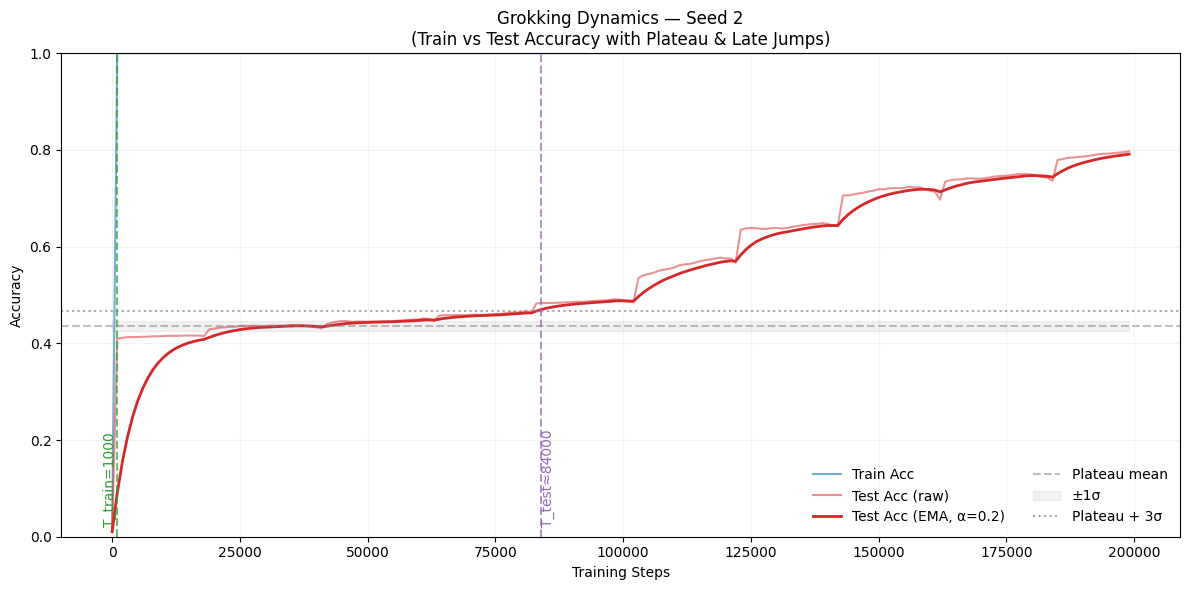

Saved figure to: seed2_grokking_colab.png


In [ ]:
#@title Grokking plot & diagnostics for Seed 2 (Colab-ready)
# If running in Colab, this single cell is all you need.

import re
import io
import math
from typing import List, Tuple, Optional, Dict

import numpy as np
import matplotlib.pyplot as plt

#========================
# 1) INPUT
#========================
LOG_SOURCE = "inline"  # "inline" | "file"

# Paste your Seed 2 log below (or switch LOG_SOURCE to "file" and upload a .txt)
raw_log = """
Step      0 | Train Acc: 0.0106 | Test Acc: 0.0103
Step   1000 | Train Acc: 1.0000 | Test Acc: 0.4098
Step   2000 | Train Acc: 1.0000 | Test Acc: 0.4113
Step   3000 | Train Acc: 1.0000 | Test Acc: 0.4127
Step   4000 | Train Acc: 1.0000 | Test Acc: 0.4127
Step   5000 | Train Acc: 1.0000 | Test Acc: 0.4130
Step   6000 | Train Acc: 1.0000 | Test Acc: 0.4134
Step   7000 | Train Acc: 1.0000 | Test Acc: 0.4137
Step   8000 | Train Acc: 1.0000 | Test Acc: 0.4145
Step   9000 | Train Acc: 1.0000 | Test Acc: 0.4145
Step  10000 | Train Acc: 1.0000 | Test Acc: 0.4148
Step  11000 | Train Acc: 1.0000 | Test Acc: 0.4155
Step  12000 | Train Acc: 1.0000 | Test Acc: 0.4155
Step  13000 | Train Acc: 1.0000 | Test Acc: 0.4155
Step  14000 | Train Acc: 1.0000 | Test Acc: 0.4159
Step  15000 | Train Acc: 1.0000 | Test Acc: 0.4162
Step  16000 | Train Acc: 1.0000 | Test Acc: 0.4159
Step  17000 | Train Acc: 1.0000 | Test Acc: 0.4159
Step  18000 | Train Acc: 1.0000 | Test Acc: 0.4152
Step  19000 | Train Acc: 1.0000 | Test Acc: 0.4286
Step  20000 | Train Acc: 1.0000 | Test Acc: 0.4304
Step  21000 | Train Acc: 1.0000 | Test Acc: 0.4325
Step  22000 | Train Acc: 1.0000 | Test Acc: 0.4330
Step  23000 | Train Acc: 1.0000 | Test Acc: 0.4341
Step  24000 | Train Acc: 1.0000 | Test Acc: 0.4341
Step  25000 | Train Acc: 1.0000 | Test Acc: 0.4359
Step  26000 | Train Acc: 1.0000 | Test Acc: 0.4362
Step  27000 | Train Acc: 1.0000 | Test Acc: 0.4359
Step  28000 | Train Acc: 1.0000 | Test Acc: 0.4362
Step  29000 | Train Acc: 1.0000 | Test Acc: 0.4359
Step  30000 | Train Acc: 1.0000 | Test Acc: 0.4355
Step  31000 | Train Acc: 1.0000 | Test Acc: 0.4366
Step  32000 | Train Acc: 1.0000 | Test Acc: 0.4362
Step  33000 | Train Acc: 1.0000 | Test Acc: 0.4366
Step  34000 | Train Acc: 1.0000 | Test Acc: 0.4369
Step  35000 | Train Acc: 1.0000 | Test Acc: 0.4373
Step  36000 | Train Acc: 1.0000 | Test Acc: 0.4373
Step  37000 | Train Acc: 1.0000 | Test Acc: 0.4366
Step  38000 | Train Acc: 1.0000 | Test Acc: 0.4354
Step  39000 | Train Acc: 1.0000 | Test Acc: 0.4341
Step  40000 | Train Acc: 1.0000 | Test Acc: 0.4330
Step  41000 | Train Acc: 1.0000 | Test Acc: 0.4307
Step  42000 | Train Acc: 1.0000 | Test Acc: 0.4398
Step  43000 | Train Acc: 1.0000 | Test Acc: 0.4426
Step  44000 | Train Acc: 1.0000 | Test Acc: 0.4447
Step  45000 | Train Acc: 1.0000 | Test Acc: 0.4462
Step  46000 | Train Acc: 1.0000 | Test Acc: 0.4458
Step  47000 | Train Acc: 1.0000 | Test Acc: 0.4444
Step  48000 | Train Acc: 1.0000 | Test Acc: 0.4451
Step  49000 | Train Acc: 1.0000 | Test Acc: 0.4447
Step  50000 | Train Acc: 1.0000 | Test Acc: 0.4447
Step  51000 | Train Acc: 1.0000 | Test Acc: 0.4451
Step  52000 | Train Acc: 1.0000 | Test Acc: 0.4447
Step  53000 | Train Acc: 1.0000 | Test Acc: 0.4454
Step  54000 | Train Acc: 1.0000 | Test Acc: 0.4451
Step  55000 | Train Acc: 1.0000 | Test Acc: 0.4458
Step  56000 | Train Acc: 1.0000 | Test Acc: 0.4469
Step  57000 | Train Acc: 1.0000 | Test Acc: 0.4469
Step  58000 | Train Acc: 1.0000 | Test Acc: 0.4483
Step  59000 | Train Acc: 1.0000 | Test Acc: 0.4490
Step  60000 | Train Acc: 1.0000 | Test Acc: 0.4493
Step  61000 | Train Acc: 1.0000 | Test Acc: 0.4518
Step  62000 | Train Acc: 1.0000 | Test Acc: 0.4501
Step  63000 | Train Acc: 1.0000 | Test Acc: 0.4462
Step  64000 | Train Acc: 1.0000 | Test Acc: 0.4573
Step  65000 | Train Acc: 1.0000 | Test Acc: 0.4582
Step  66000 | Train Acc: 1.0000 | Test Acc: 0.4580
Step  67000 | Train Acc: 1.0000 | Test Acc: 0.4584
Step  68000 | Train Acc: 1.0000 | Test Acc: 0.4582
Step  69000 | Train Acc: 1.0000 | Test Acc: 0.4582
Step  70000 | Train Acc: 1.0000 | Test Acc: 0.4587
Step  71000 | Train Acc: 1.0000 | Test Acc: 0.4594
Step  72000 | Train Acc: 1.0000 | Test Acc: 0.4587
Step  73000 | Train Acc: 1.0000 | Test Acc: 0.4586
Step  74000 | Train Acc: 1.0000 | Test Acc: 0.4596
Step  75000 | Train Acc: 1.0000 | Test Acc: 0.4607
Step  76000 | Train Acc: 1.0000 | Test Acc: 0.4607
Step  77000 | Train Acc: 1.0000 | Test Acc: 0.4623
Step  78000 | Train Acc: 1.0000 | Test Acc: 0.4637
Step  79000 | Train Acc: 1.0000 | Test Acc: 0.4640
Step  80000 | Train Acc: 1.0000 | Test Acc: 0.4642
Step  81000 | Train Acc: 1.0000 | Test Acc: 0.4671
Step  82000 | Train Acc: 1.0000 | Test Acc: 0.4621
Step  83000 | Train Acc: 1.0000 | Test Acc: 0.4821
Step  84000 | Train Acc: 1.0000 | Test Acc: 0.4834
Step  85000 | Train Acc: 1.0000 | Test Acc: 0.4832
Step  86000 | Train Acc: 1.0000 | Test Acc: 0.4832
Step  87000 | Train Acc: 1.0000 | Test Acc: 0.4839
Step  88000 | Train Acc: 1.0000 | Test Acc: 0.4842
Step  89000 | Train Acc: 1.0000 | Test Acc: 0.4848
Step  90000 | Train Acc: 1.0000 | Test Acc: 0.4851
Step  91000 | Train Acc: 1.0000 | Test Acc: 0.4858
Step  92000 | Train Acc: 1.0000 | Test Acc: 0.4858
Step  93000 | Train Acc: 1.0000 | Test Acc: 0.4862
Step  94000 | Train Acc: 1.0000 | Test Acc: 0.4874
Step  95000 | Train Acc: 1.0000 | Test Acc: 0.4878
Step  96000 | Train Acc: 1.0000 | Test Acc: 0.4885
Step  97000 | Train Acc: 1.0000 | Test Acc: 0.4892
Step  98000 | Train Acc: 1.0000 | Test Acc: 0.4910
Step  99000 | Train Acc: 1.0000 | Test Acc: 0.4906
Step 100000 | Train Acc: 1.0000 | Test Acc: 0.4883
Step 101000 | Train Acc: 1.0000 | Test Acc: 0.4858
Step 102000 | Train Acc: 1.0000 | Test Acc: 0.4848
Step 103000 | Train Acc: 1.0000 | Test Acc: 0.5352
Step 104000 | Train Acc: 1.0000 | Test Acc: 0.5409
Step 105000 | Train Acc: 1.0000 | Test Acc: 0.5432
Step 106000 | Train Acc: 1.0000 | Test Acc: 0.5461
Step 107000 | Train Acc: 1.0000 | Test Acc: 0.5499
Step 108000 | Train Acc: 1.0000 | Test Acc: 0.5524
Step 109000 | Train Acc: 1.0000 | Test Acc: 0.5538
Step 110000 | Train Acc: 1.0000 | Test Acc: 0.5567
Step 111000 | Train Acc: 1.0000 | Test Acc: 0.5613
Step 112000 | Train Acc: 1.0000 | Test Acc: 0.5631
Step 113000 | Train Acc: 1.0000 | Test Acc: 0.5641
Step 114000 | Train Acc: 1.0000 | Test Acc: 0.5668
Step 115000 | Train Acc: 1.0000 | Test Acc: 0.5693
Step 116000 | Train Acc: 1.0000 | Test Acc: 0.5721
Step 117000 | Train Acc: 1.0000 | Test Acc: 0.5731
Step 118000 | Train Acc: 1.0000 | Test Acc: 0.5751
Step 119000 | Train Acc: 1.0000 | Test Acc: 0.5772
Step 120000 | Train Acc: 1.0000 | Test Acc: 0.5755
Step 121000 | Train Acc: 1.0000 | Test Acc: 0.5756
Step 122000 | Train Acc: 1.0000 | Test Acc: 0.5666
Step 123000 | Train Acc: 1.0000 | Test Acc: 0.6348
Step 124000 | Train Acc: 1.0000 | Test Acc: 0.6376
Step 125000 | Train Acc: 1.0000 | Test Acc: 0.6385
Step 126000 | Train Acc: 1.0000 | Test Acc: 0.6382
Step 127000 | Train Acc: 1.0000 | Test Acc: 0.6366
Step 128000 | Train Acc: 1.0000 | Test Acc: 0.6366
Step 129000 | Train Acc: 1.0000 | Test Acc: 0.6380
Step 130000 | Train Acc: 1.0000 | Test Acc: 0.6385
Step 131000 | Train Acc: 1.0000 | Test Acc: 0.6374
Step 132000 | Train Acc: 1.0000 | Test Acc: 0.6382
Step 133000 | Train Acc: 1.0000 | Test Acc: 0.6406
Step 134000 | Train Acc: 1.0000 | Test Acc: 0.6426
Step 135000 | Train Acc: 1.0000 | Test Acc: 0.6440
Step 136000 | Train Acc: 1.0000 | Test Acc: 0.6454
Step 137000 | Train Acc: 1.0000 | Test Acc: 0.6465
Step 138000 | Train Acc: 1.0000 | Test Acc: 0.6470
Step 139000 | Train Acc: 1.0000 | Test Acc: 0.6484
Step 140000 | Train Acc: 1.0000 | Test Acc: 0.6468
Step 141000 | Train Acc: 1.0000 | Test Acc: 0.6436
Step 142000 | Train Acc: 1.0000 | Test Acc: 0.6435
Step 143000 | Train Acc: 1.0000 | Test Acc: 0.7058
Step 144000 | Train Acc: 1.0000 | Test Acc: 0.7058
Step 145000 | Train Acc: 1.0000 | Test Acc: 0.7076
Step 146000 | Train Acc: 1.0000 | Test Acc: 0.7097
Step 147000 | Train Acc: 1.0000 | Test Acc: 0.7113
Step 148000 | Train Acc: 1.0000 | Test Acc: 0.7141
Step 149000 | Train Acc: 1.0000 | Test Acc: 0.7156
Step 150000 | Train Acc: 1.0000 | Test Acc: 0.7187
Step 151000 | Train Acc: 1.0000 | Test Acc: 0.7184
Step 152000 | Train Acc: 1.0000 | Test Acc: 0.7205
Step 153000 | Train Acc: 1.0000 | Test Acc: 0.7209
Step 154000 | Train Acc: 1.0000 | Test Acc: 0.7209
Step 155000 | Train Acc: 1.0000 | Test Acc: 0.7216
Step 156000 | Train Acc: 1.0000 | Test Acc: 0.7237
Step 157000 | Train Acc: 1.0000 | Test Acc: 0.7219
Step 158000 | Train Acc: 1.0000 | Test Acc: 0.7226
Step 159000 | Train Acc: 1.0000 | Test Acc: 0.7187
Step 160000 | Train Acc: 1.0000 | Test Acc: 0.7157
Step 161000 | Train Acc: 1.0000 | Test Acc: 0.7131
Step 162000 | Train Acc: 1.0000 | Test Acc: 0.6971
Step 163000 | Train Acc: 1.0000 | Test Acc: 0.7341
Step 164000 | Train Acc: 1.0000 | Test Acc: 0.7370
Step 165000 | Train Acc: 1.0000 | Test Acc: 0.7386
Step 166000 | Train Acc: 1.0000 | Test Acc: 0.7389
Step 167000 | Train Acc: 1.0000 | Test Acc: 0.7407
Step 168000 | Train Acc: 1.0000 | Test Acc: 0.7411
Step 169000 | Train Acc: 1.0000 | Test Acc: 0.7403
Step 170000 | Train Acc: 1.0000 | Test Acc: 0.7403
Step 171000 | Train Acc: 1.0000 | Test Acc: 0.7418
Step 172000 | Train Acc: 1.0000 | Test Acc: 0.7435
Step 173000 | Train Acc: 1.0000 | Test Acc: 0.7453
Step 174000 | Train Acc: 1.0000 | Test Acc: 0.7458
Step 175000 | Train Acc: 1.0000 | Test Acc: 0.7465
Step 176000 | Train Acc: 1.0000 | Test Acc: 0.7476
Step 177000 | Train Acc: 1.0000 | Test Acc: 0.7497
Step 178000 | Train Acc: 1.0000 | Test Acc: 0.7499
Step 179000 | Train Acc: 1.0000 | Test Acc: 0.7497
Step 180000 | Train Acc: 1.0000 | Test Acc: 0.7490
Step 181000 | Train Acc: 1.0000 | Test Acc: 0.7460
Step 182000 | Train Acc: 1.0000 | Test Acc: 0.7439
Step 183000 | Train Acc: 1.0000 | Test Acc: 0.7426
Step 184000 | Train Acc: 1.0000 | Test Acc: 0.7361
Step 185000 | Train Acc: 1.0000 | Test Acc: 0.7793
Step 186000 | Train Acc: 1.0000 | Test Acc: 0.7809
Step 187000 | Train Acc: 1.0000 | Test Acc: 0.7834
Step 188000 | Train Acc: 1.0000 | Test Acc: 0.7841
Step 189000 | Train Acc: 1.0000 | Test Acc: 0.7852
Step 190000 | Train Acc: 1.0000 | Test Acc: 0.7862
Step 191000 | Train Acc: 1.0000 | Test Acc: 0.7873
Step 192000 | Train Acc: 1.0000 | Test Acc: 0.7891
Step 193000 | Train Acc: 1.0000 | Test Acc: 0.7908
Step 194000 | Train Acc: 1.0000 | Test Acc: 0.7919
Step 195000 | Train Acc: 1.0000 | Test Acc: 0.7922
Step 196000 | Train Acc: 1.0000 | Test Acc: 0.7933
Step 197000 | Train Acc: 1.0000 | Test Acc: 0.7942
Step 198000 | Train Acc: 1.0000 | Test Acc: 0.7953
Step 199000 | Train Acc: 1.0000 | Test Acc: 0.7970
""".strip()


#========================
# 2) HELPERS
#========================
def parse_log(text: str) -> Dict[str, List[float]]:
    """Parse 'Step ... | Train Acc: ... | Test Acc: ...' lines."""
    steps, train, test = [], [], []
    pat = re.compile(r"Step\s+(\d+)\s*\|\s*Train Acc:\s*([0-9.]+)\s*\|\s*Test Acc:\s*([0-9.]+)")
    for line in text.splitlines():
        m = pat.search(line)
        if m:
            steps.append(int(m.group(1)))
            train.append(float(m.group(2)))
            test.append(float(m.group(3)))
    return {"steps": steps, "train": train, "test": test}

def ema(x: np.ndarray, alpha: float=0.2) -> np.ndarray:
    y = np.zeros_like(x, dtype=float)
    if len(x) == 0:
        return y
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha*x[i] + (1-alpha)*y[i-1]
    return y

def plateau_stats(steps: List[int], test: List[float],
                  start: int=10_000, end: int=60_000) -> Tuple[float, float]:
    mask = [(start <= s <= end) for s in steps]
    arr = np.array([t for t, m in zip(test, mask) if m], dtype=float)
    if arr.size == 0:
        return float('nan'), float('nan')
    return float(arr.mean()), float(arr.std(ddof=1) if len(arr) > 1 else 0.0)

def find_first_memorization_step(steps: List[int], train: List[float], thr: float=0.99) -> Optional[int]:
    for s, a in zip(steps, train):
        if a >= thr:
            return s
    return None

def detect_change_points(steps: List[int], test: List[float],
                         min_step: int=50_000,
                         min_jump: float=0.04,
                         ema_alpha: float=0.2) -> List[int]:
    """
    Heuristic change-point detector: mark indices where EMA(test) increases
    more than min_jump vs previous entry, after min_step.
    """
    t = np.array(test, dtype=float)
    e = ema(t, alpha=ema_alpha)
    cps = []
    for i in range(1, len(e)):
        if steps[i] >= min_step and (e[i] - e[i-1]) >= min_jump:
            cps.append(i)
    # Deduplicate closely spaced points (keep first in a burst)
    filtered = []
    last_i = -10**9
    for i in cps:
        if steps[i] - steps[last_i] if last_i >= 0 else 10**9 >= 3000:
            filtered.append(i)
            last_i = i
    return filtered

def estimate_grokking_time(steps: List[int],
                           train: List[float],
                           test: List[float],
                           sustain_k: int=5,
                           method: str="plateau+3sigma",
                           plateau_range: Tuple[int,int]=(10_000, 60_000)) -> Tuple[Optional[int], Optional[int]]:
    """
    Returns (T_train, T_test_est) where:
      - T_train: first step with train_acc >= 0.99
      - T_test_est: first step AFTER T_train where test surpasses a criterion and is sustained for 'sustain_k' evals.
    Methods:
      - "plateau+3sigma": threshold = plateau_mean + 3*plateau_std
      - "absolute=0.75": absolute threshold at 0.75
    """
    T_train = find_first_memorization_step(steps, train, thr=0.99)
    if T_train is None:
        return None, None

    t = np.array(test, dtype=float)
    e = ema(t, alpha=0.2)

    if method.startswith("plateau"):
        mu, sd = plateau_stats(steps, test, plateau_range[0], plateau_range[1])
        if not (math.isfinite(mu) and math.isfinite(sd)):
            return T_train, None
        thr = mu + 3*sd
    elif method.startswith("absolute="):
        thr = float(method.split("=")[1])
    else:
        raise ValueError("Unknown method")

    # Find first sustained crossing after T_train
    for i in range(len(e)):
        if steps[i] <= T_train:
            continue
        if e[i] >= thr:
            # require sustain_k consecutive points above thr
            j_end = min(i + sustain_k, len(e))
            if np.all(e[i:j_end] >= thr):
                return T_train, steps[i]
    return T_train, None

#========================
# 3) READ & PARSE
#========================
if LOG_SOURCE == "file":
    # In Colab: run this cell, then from the file browser upload a .txt
    # (or use files.upload()). Here we assume a file named 'seed2_log.txt'.
    with open("seed2_log.txt", "r") as f:
        text = f.read()
else:
    text = raw_log

data = parse_log(text)
steps, train, test = data["steps"], data["train"], data["test"]
if not steps:
    raise ValueError("No lines parsed. Check your log format.")

#========================
# 4) METRICS & DETECTION
#========================
mu, sd = plateau_stats(steps, test, start=10_000, end=60_000)
cps_idx = detect_change_points(steps, test, min_step=50_000, min_jump=0.04, ema_alpha=0.2)

T_train, T_test_est = estimate_grokking_time(
    steps, train, test,
    sustain_k=5,
    method="plateau+3sigma",       # or "absolute=0.75"
    plateau_range=(10_000, 60_000)
)

print(f"Parsed {len(steps)} evaluations.")
print(f"Early plateau (10k–60k): mean={mu:.3f}, std={sd:.3f}")
print(f"First memorization step (T_train ≥ 0.99): {T_train}")
print(f"Estimated grokking time (T_test_est): {T_test_est} (method=plateau+3σ)")
print("Detected change-points at steps:", [steps[i] for i in cps_idx])

#========================
# 5) PLOT
#========================
test_ema = ema(np.array(test, dtype=float), alpha=0.2)

plt.figure(figsize=(12,6))
plt.plot(steps, train, label="Train Acc", color="tab:blue", alpha=0.6)
plt.plot(steps, test, label="Test Acc (raw)", color="tab:red", alpha=0.5)
plt.plot(steps, test_ema, label="Test Acc (EMA, α=0.2)", color="tab:red", linewidth=2.0)

# Plateau band
if math.isfinite(mu) and math.isfinite(sd):
    plt.axhline(mu, color="gray", linestyle="--", alpha=0.5, label="Plateau mean")
    plt.fill_between(steps, mu - sd, mu + sd, color="gray", alpha=0.1, label="±1σ")
    thr = mu + 3*sd
    plt.axhline(thr, color="gray", linestyle=":", alpha=0.7, label="Plateau + 3σ")

# Vertical markers
if T_train is not None:
    plt.axvline(T_train, color="tab:green", linestyle="--", alpha=0.7)
    plt.text(T_train, 0.02, f"T_train={T_train}", rotation=90, va="bottom", ha="right", color="tab:green")

if T_test_est is not None:
    plt.axvline(T_test_est, color="tab:purple", linestyle="--", alpha=0.7)
    plt.text(T_test_est, 0.02, f"T_test≈{T_test_est}", rotation=90, va="bottom", ha="left", color="tab:purple")

# Change-point vertical lines
for i in cps_idx:
    s = steps[i]
    plt.axvline(s, color="black", linestyle=":", alpha=0.25)

plt.title("Grokking Dynamics — Seed 2\n(Train vs Test Accuracy with Plateau & Late Jumps)")
plt.xlabel("Training Steps")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.legend(loc="lower right", ncol=2, frameon=False)
plt.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("seed2_grokking_colab.png", dpi=150)
plt.show()

print("Saved figure to: seed2_grokking_colab.png")

Latest code

Using device: cuda

Running seed 0
Step      0 | Train 0.0101 | Test 0.0089
Step   1000 | Train 1.0000 | Test 0.1990
Step   2000 | Train 1.0000 | Test 0.1990
Step   3000 | Train 1.0000 | Test 0.1990
Step   4000 | Train 1.0000 | Test 0.1990
Step   5000 | Train 1.0000 | Test 0.1990
Step   6000 | Train 1.0000 | Test 0.1990
Step   7000 | Train 1.0000 | Test 0.1990
Step   8000 | Train 1.0000 | Test 0.1990
Step   9000 | Train 1.0000 | Test 0.1993
Step  10000 | Train 1.0000 | Test 0.1998
Step  11000 | Train 1.0000 | Test 0.2006
Step  12000 | Train 1.0000 | Test 0.2032
Step  13000 | Train 1.0000 | Test 0.2117
Step  14000 | Train 1.0000 | Test 0.2319
Step  15000 | Train 1.0000 | Test 0.2747
Step  16000 | Train 1.0000 | Test 0.3423
Step  17000 | Train 1.0000 | Test 0.4393
Step  18000 | Train 1.0000 | Test 0.5615
Step  19000 | Train 1.0000 | Test 0.6634
Step  20000 | Train 1.0000 | Test 0.7442
Step  21000 | Train 1.0000 | Test 0.8047
Step  22000 | Train 1.0000 | Test 0.8491
Step  23000 | Train 1.

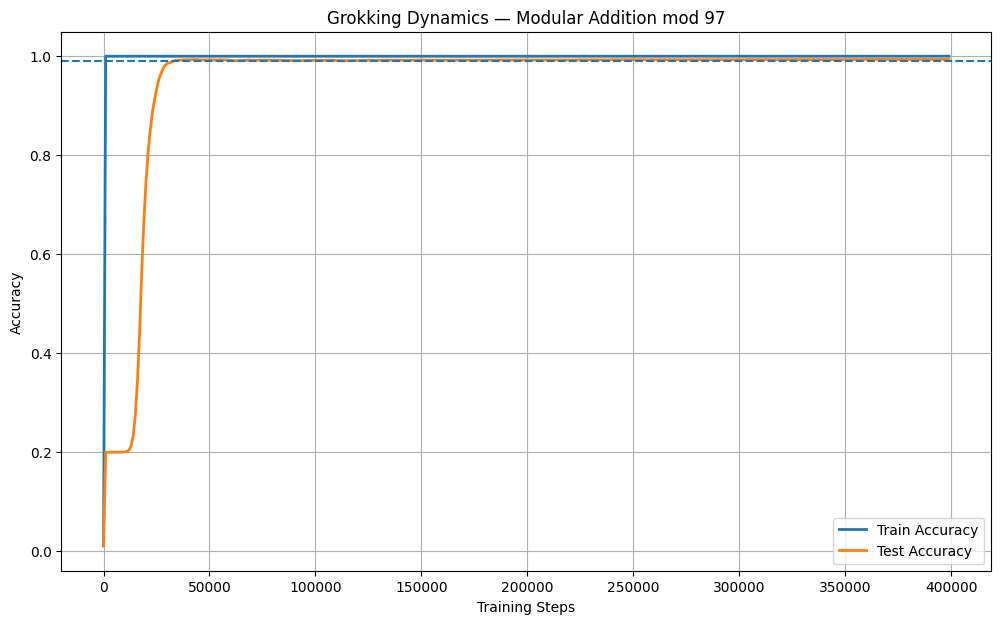

In [ ]:
# ============================================================
# GROKKING EXPERIMENT — Modular Addition mod 97
# Reliable Grokking Version (SGD, Colab T4 Optimized)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import time
import matplotlib.pyplot as plt

# ============================================================
# Configuration — GROKKING RELIABLE SETTINGS
# ============================================================

P = 97
TRAIN_FRACTION = 0.2
STEPS = 400_000
LOG_EVERY = 1000

WIDTH = 256
DEPTH = 2

LR = 1e-2
WEIGHT_DECAY = 2e-3
MOMENTUM = 0.9

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

# ============================================================
# Dataset
# ============================================================

def generate_data(p, train_fraction, seed):

    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split = int(len(pairs) * train_fraction)

    train_pairs = pairs[:split]
    test_pairs = pairs[split:]

    def convert(data):
        x = torch.tensor(data, dtype=torch.long)
        y = (x[:,0] + x[:,1]) % p
        return x.to(DEVICE), y.to(DEVICE)

    return convert(train_pairs), convert(test_pairs)

# ============================================================
# Model
# ============================================================

class GrokkingMLP(nn.Module):

    def __init__(self, p, width, depth):

        super().__init__()

        self.embed = nn.Embedding(p, width)

        layers = []
        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(nn.GELU())

        self.mlp = nn.Sequential(*layers)
        self.output = nn.Linear(width, p)

    def forward(self, x):

        a = self.embed(x[:,0])
        b = self.embed(x[:,1])

        h = a + b
        h = self.mlp(h)

        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, targets):

    preds = logits.argmax(dim=1)

    return (preds == targets).float().mean().item()

# ============================================================
# Training
# ============================================================

def run(seed=0):

    print(f"\nRunning seed {seed}")

    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_data(
        P, TRAIN_FRACTION, seed
    )

    model = GrokkingMLP(P, WIDTH, DEPTH).to(DEVICE)

    # CRITICAL: SGD optimizer (NOT Adam)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    train_accs = []
    test_accs = []
    steps = []

    T_train = None
    T_test = None

    start_time = time.time()

    for step in range(STEPS):

        logits = model(train_x)
        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % LOG_EVERY == 0:

            model.eval()

            with torch.no_grad():

                train_acc = accuracy(model(train_x), train_y)
                test_acc = accuracy(model(test_x), test_y)

            model.train()

            steps.append(step)
            train_accs.append(train_acc)
            test_accs.append(test_acc)

            print(f"Step {step:6d} | Train {train_acc:.4f} | Test {test_acc:.4f}")

            if train_acc >= 0.99 and T_train is None:
                T_train = step

            if test_acc >= 0.99 and T_test is None:
                T_test = step
                print("\nGROKKING DETECTED at step", step)

    total_time = time.time() - start_time

    print("\nFinished in", round(total_time, 2), "seconds")

    if T_test:
        print("Grokking delay:", T_test - T_train)
    else:
        print("No grokking detected")

    return steps, train_accs, test_accs

# ============================================================
# Run experiment
# ============================================================

steps, train_accs, test_accs = run(seed=0)

# ============================================================
# Plot results
# ============================================================

plt.figure(figsize=(12,7))

plt.plot(steps, train_accs, label="Train Accuracy", linewidth=2)
plt.plot(steps, test_accs, label="Test Accuracy", linewidth=2)

plt.axhline(0.99, linestyle="--")

plt.xlabel("Training Steps")
plt.ylabel("Accuracy")
plt.title("Grokking Dynamics — Modular Addition mod 97")

plt.legend()
plt.grid()

plt.show()


In [ ]:
# ============================================================
# GROKKING DEPTH EXPERIMENT (UPDATED — GROKKING RELIABLE)
# Does deeper network grok faster?
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import time
import pandas as pd

# ============================================================
# Configuration (UPDATED FOR RELIABLE GROKKING)
# ============================================================

P = 97
TRAIN_FRACTION = 0.2     # critical
STEPS = 400_000          # allow grokking transition
LR = 1e-2                # required for SGD grokking
WEIGHT_DECAY = 2e-3      # critical strength
MOMENTUM = 0.9
SEEDS = 5
LOG_EVERY = 2000

DEPTHS = [2, 4, 8]
WIDTH = 256              # improved capacity

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# ============================================================
# Dataset
# ============================================================

def generate_modular_addition_data(p=97, train_fraction=0.2, seed=0):

    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split_idx = int(len(pairs) * train_fraction)

    train_pairs = pairs[:split_idx]
    test_pairs = pairs[split_idx:]

    def to_tensor(data):

        x = torch.tensor(data, dtype=torch.long).to(DEVICE)
        y = (x[:, 0] + x[:, 1]) % p

        return x, y.to(DEVICE)

    return to_tensor(train_pairs), to_tensor(test_pairs)

# ============================================================
# Model
# ============================================================

class ModularMLP(nn.Module):

    def __init__(self, p=97, width=256, depth=4):

        super().__init__()

        self.embed = nn.Embedding(p, width)

        layers = []

        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(nn.GELU())

        self.mlp = nn.Sequential(*layers)

        self.output = nn.Linear(width, p)

    def forward(self, x):

        a = self.embed(x[:, 0])
        b = self.embed(x[:, 1])

        h = a + b
        h = self.mlp(h)

        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, targets):

    preds = logits.argmax(dim=-1)

    return (preds == targets).float().mean().item()

# ============================================================
# Training
# ============================================================

def train_model(depth, seed):

    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_modular_addition_data(
        p=P,
        train_fraction=TRAIN_FRACTION,
        seed=seed
    )

    model = ModularMLP(p=P, width=WIDTH, depth=depth).to(DEVICE)

    # CRITICAL: SGD optimizer
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    T_train_acc = None
    T_test_acc = None

    start_time = time.time()

    for step in range(STEPS):

        logits = model(train_x)

        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % LOG_EVERY == 0:

            model.eval()

            with torch.no_grad():

                train_acc = accuracy(model(train_x), train_y)
                test_acc = accuracy(model(test_x), test_y)

            if train_acc >= 0.99 and T_train_acc is None:
                T_train_acc = step

            if test_acc >= 0.99 and T_test_acc is None:
                T_test_acc = step

            model.train()

    delay = None

    if T_train_acc is not None and T_test_acc is not None:

        delay = T_test_acc - T_train_acc

    total_time = round(time.time() - start_time, 2)

    return {
        "depth": depth,
        "seed": seed,
        "T_train": T_train_acc,
        "T_test": T_test_acc,
        "delay": delay,
        "time_sec": total_time
    }

# ============================================================
# Run Experiment
# ============================================================

results = []

for depth in DEPTHS:

    print(f"\n==============================")
    print(f"Running Depth = {depth}")
    print(f"==============================")

    for seed in range(SEEDS):

        res = train_model(depth, seed)

        results.append(res)

        print(res)

df = pd.DataFrame(results)

print("\n====================================")
print("SUMMARY BY DEPTH")
print("====================================")

print(df.groupby("depth")["delay"].mean())

print("\nFull Results:")
print(df)


Using device: cuda

Running Depth = 2
{'depth': 2, 'seed': 0, 'T_train': 2000, 'T_test': 34000, 'delay': 32000, 'time_sec': 643.27}
{'depth': 2, 'seed': 1, 'T_train': 2000, 'T_test': 22000, 'delay': 20000, 'time_sec': 663.19}
{'depth': 2, 'seed': 2, 'T_train': 2000, 'T_test': 28000, 'delay': 26000, 'time_sec': 631.14}
{'depth': 2, 'seed': 3, 'T_train': 2000, 'T_test': None, 'delay': None, 'time_sec': 644.39}
{'depth': 2, 'seed': 4, 'T_train': 2000, 'T_test': 212000, 'delay': 210000, 'time_sec': 634.93}

Running Depth = 4


In [ ]:
# ============================================================
# GROKKING ARCHITECTURE EXPERIMENT (UPDATED — RELIABLE)
# MLP vs Transformer
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import pandas as pd
import time

# ============================================================
# Configuration (UPDATED FOR GROKKING)
# ============================================================

P = 97
TRAIN_FRACTION = 0.2
STEPS = 400_000

LR = 1e-2
WEIGHT_DECAY = 2e-3
MOMENTUM = 0.9

SEEDS = 5
LOG_EVERY = 2000

WIDTH = 256
DEPTH = 4
HEADS = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True

# ============================================================
# Dataset
# ============================================================

def generate_modular_addition_data(p, train_fraction, seed):

    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split_idx = int(len(pairs) * train_fraction)

    train_pairs = pairs[:split_idx]
    test_pairs = pairs[split_idx:]

    def to_tensor(data):

        x = torch.tensor(data, dtype=torch.long).to(DEVICE)
        y = (x[:, 0] + x[:, 1]) % p

        return x, y.to(DEVICE)

    return to_tensor(train_pairs), to_tensor(test_pairs)

# ============================================================
# Models
# ============================================================

class ModularMLP(nn.Module):

    def __init__(self, p=P, width=WIDTH, depth=DEPTH):

        super().__init__()

        self.embed = nn.Embedding(p, width)

        layers = []

        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(nn.GELU())

        self.mlp = nn.Sequential(*layers)

        self.output = nn.Linear(width, p)

    def forward(self, x):

        a = self.embed(x[:, 0])
        b = self.embed(x[:, 1])

        h = a + b
        h = self.mlp(h)

        return self.output(h)


class ModularTransformer(nn.Module):

    def __init__(self, p=P, width=WIDTH, depth=DEPTH, heads=HEADS):

        super().__init__()

        self.embed = nn.Embedding(p, width)

        self.pos_embed = nn.Parameter(torch.randn(2, width))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=width,
            nhead=heads,
            dim_feedforward=width * 4,
            activation='gelu',
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.output = nn.Linear(width, p)

    def forward(self, x):

        h = self.embed(x)

        h = h + self.pos_embed

        h = self.transformer(h)

        h = h.mean(dim=1)

        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, targets):

    preds = logits.argmax(dim=-1)

    return (preds == targets).float().mean().item()

# ============================================================
# Training
# ============================================================

def train_model(model_fn, seed):

    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_modular_addition_data(
        P, TRAIN_FRACTION, seed
    )

    model = model_fn().to(DEVICE)

    # CRITICAL: SGD optimizer
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    T_train_acc = None
    T_test_acc = None

    start_time = time.time()

    for step in range(STEPS):

        logits = model(train_x)

        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % LOG_EVERY == 0:

            model.eval()

            with torch.no_grad():

                train_acc = accuracy(model(train_x), train_y)
                test_acc = accuracy(model(test_x), test_y)

            if train_acc >= 0.99 and T_train_acc is None:
                T_train_acc = step

            if test_acc >= 0.99 and T_test_acc is None:
                T_test_acc = step

            model.train()

    delay = None

    if T_train_acc is not None and T_test_acc is not None:

        delay = T_test_acc - T_train_acc

    total_time = round(time.time() - start_time, 2)

    return T_train_acc, T_test_acc, delay, total_time

# ============================================================
# Run Experiment
# ============================================================

results = []

architectures = {

    "MLP": lambda: ModularMLP(),

    "Transformer": lambda: ModularTransformer()

}

for name, model_fn in architectures.items():

    print(f"\n==============================")
    print(f"Running Architecture: {name}")
    print(f"==============================")

    for seed in range(SEEDS):

        T_train, T_test, delay, runtime = train_model(model_fn, seed)

        result = {

            "architecture": name,
            "seed": seed,
            "T_train": T_train,
            "T_test": T_test,
            "delay": delay,
            "runtime_sec": runtime

        }

        results.append(result)

        print(result)

df = pd.DataFrame(results)

print("\n====================================")
print("SUMMARY BY ARCHITECTURE")
print("====================================")

print(df.groupby("architecture")["delay"].mean())

print("\nFull Results:")
print(df)


In [ ]:
# ============================================================
# GROKKING ACTIVATION EXPERIMENT (H3) — UPDATED RELIABLE VERSION
# ReLU vs GELU vs Tanh
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import pandas as pd
import time

# ============================================================
# Configuration (UPDATED FOR RELIABLE GROKKING)
# ============================================================

P = 97
TRAIN_FRACTION = 0.2
STEPS = 400_000

LR = 1e-2
WEIGHT_DECAY = 2e-3
MOMENTUM = 0.9

SEEDS = 5
LOG_EVERY = 2000

WIDTH = 256
DEPTH = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True

# ============================================================
# Dataset
# ============================================================

def generate_modular_addition_data(p, train_fraction, seed):

    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split_idx = int(len(pairs) * train_fraction)

    train_pairs = pairs[:split_idx]
    test_pairs = pairs[split_idx:]

    def to_tensor(data):

        x = torch.tensor(data, dtype=torch.long).to(DEVICE)
        y = (x[:, 0] + x[:, 1]) % p

        return x, y.to(DEVICE)

    return to_tensor(train_pairs), to_tensor(test_pairs)

# ============================================================
# Model with Configurable Activation
# ============================================================

class ModularMLP(nn.Module):

    def __init__(self, p=P, width=WIDTH, depth=DEPTH, activation="gelu"):

        super().__init__()

        self.embed = nn.Embedding(p, width)

        if activation == "relu":
            act_layer = nn.ReLU

        elif activation == "gelu":
            act_layer = nn.GELU

        elif activation == "tanh":
            act_layer = nn.Tanh

        else:
            raise ValueError("Unknown activation")

        layers = []

        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(act_layer())

        self.mlp = nn.Sequential(*layers)

        self.output = nn.Linear(width, p)

    def forward(self, x):

        a = self.embed(x[:, 0])
        b = self.embed(x[:, 1])

        h = a + b
        h = self.mlp(h)

        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, targets):

    preds = logits.argmax(dim=-1)

    return (preds == targets).float().mean().item()

# ============================================================
# Training Function
# ============================================================

def train_model(activation, seed):

    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_modular_addition_data(
        P, TRAIN_FRACTION, seed
    )

    model = ModularMLP(
        activation=activation
    ).to(DEVICE)

    # CRITICAL: SGD optimizer for grokking
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    T_train_acc = None
    T_test_acc = None

    start_time = time.time()

    for step in range(STEPS):

        logits = model(train_x)

        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % LOG_EVERY == 0:

            model.eval()

            with torch.no_grad():

                train_acc = accuracy(model(train_x), train_y)
                test_acc = accuracy(model(test_x), test_y)

            if train_acc >= 0.99 and T_train_acc is None:
                T_train_acc = step

            if test_acc >= 0.99 and T_test_acc is None:
                T_test_acc = step

            model.train()

    total_time = time.time() - start_time

    delay = None

    if T_train_acc is not None and T_test_acc is not None:

        delay = T_test_acc - T_train_acc

    return {

        "activation": activation,
        "seed": seed,
        "T_train": T_train_acc,
        "T_test": T_test_acc,
        "delay": delay,
        "time_sec": round(total_time, 2)

    }

# ============================================================
# Run Experiment
# ============================================================

activations = ["relu", "gelu", "tanh"]

results = []

for act in activations:

    print(f"\n==============================")
    print(f"Running Activation: {act.upper()}")
    print(f"==============================")

    for seed in range(SEEDS):

        res = train_model(act, seed)

        results.append(res)

        print(res)

df = pd.DataFrame(results)

print("\n====================================")
print("SUMMARY BY ACTIVATION")
print("====================================")

print(df.groupby("activation")["delay"].mean())

print("\nFull Results:")
print(df)


In [ ]:
# ============================================================
# GROKKING WEIGHT DECAY SWEEP (UPDATED — RELIABLE)
# weight_decay sweep across grokking regime
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import pandas as pd
import time

# ============================================================
# Configuration (UPDATED FOR GROKKING RELIABILITY)
# ============================================================

P = 97
TRAIN_FRACTION = 0.2
STEPS = 400_000

LR = 1e-2
MOMENTUM = 0.9

SEEDS = 5
LOG_EVERY = 2000

WIDTH = 256
DEPTH = 4
ACTIVATION = "gelu"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# Expanded sweep around critical grokking region
WEIGHT_DECAYS = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 2e-3, 5e-3]

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True

# ============================================================
# Dataset
# ============================================================

def generate_modular_addition_data(p, train_fraction, seed):

    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split_idx = int(len(pairs) * train_fraction)

    train_pairs = pairs[:split_idx]
    test_pairs = pairs[split_idx:]

    def to_tensor(data):

        x = torch.tensor(data, dtype=torch.long).to(DEVICE)
        y = (x[:, 0] + x[:, 1]) % p

        return x, y.to(DEVICE)

    return to_tensor(train_pairs), to_tensor(test_pairs)

# ============================================================
# Model
# ============================================================

class ModularMLP(nn.Module):

    def __init__(self, p=P, width=WIDTH, depth=DEPTH, activation=ACTIVATION):

        super().__init__()

        self.embed = nn.Embedding(p, width)

        if activation == "relu":
            act_layer = nn.ReLU
        elif activation == "gelu":
            act_layer = nn.GELU
        elif activation == "tanh":
            act_layer = nn.Tanh
        else:
            raise ValueError("Unknown activation")

        layers = []

        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(act_layer())

        self.mlp = nn.Sequential(*layers)

        self.output = nn.Linear(width, p)

    def forward(self, x):

        a = self.embed(x[:, 0])
        b = self.embed(x[:, 1])

        h = a + b
        h = self.mlp(h)

        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, targets):

    preds = logits.argmax(dim=-1)

    return (preds == targets).float().mean().item()

# ============================================================
# Training Function
# ============================================================

def train_model(weight_decay, seed):

    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_modular_addition_data(
        P, TRAIN_FRACTION, seed
    )

    model = ModularMLP().to(DEVICE)

    # CRITICAL: SGD optimizer
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=weight_decay
    )

    T_train_acc = None
    T_test_acc = None

    start_time = time.time()

    for step in range(STEPS):

        logits = model(train_x)

        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % LOG_EVERY == 0:

            model.eval()

            with torch.no_grad():

                train_acc = accuracy(model(train_x), train_y)
                test_acc = accuracy(model(test_x), test_y)

            if train_acc >= 0.99 and T_train_acc is None:
                T_train_acc = step

            if test_acc >= 0.99 and T_test_acc is None:
                T_test_acc = step

            model.train()

    total_time = time.time() - start_time

    delay = None

    if T_train_acc is not None and T_test_acc is not None:

        delay = T_test_acc - T_train_acc

    return {

        "weight_decay": weight_decay,
        "seed": seed,
        "T_train": T_train_acc,
        "T_test": T_test_acc,
        "delay": delay,
        "time_sec": round(total_time, 2)

    }

# ============================================================
# Run Experiment
# ============================================================

results = []

for wd in WEIGHT_DECAYS:

    print(f"\n==============================")
    print(f"Running Weight Decay: {wd}")
    print(f"==============================")

    for seed in range(SEEDS):

        res = train_model(wd, seed)

        results.append(res)

        print(res)

df = pd.DataFrame(results)

print("\n====================================")
print("SUMMARY BY WEIGHT DECAY")
print("====================================")

print(df.groupby("weight_decay")["delay"].mean())

print("\nFull Results:")
print(df)


Additional unified experiments for later run.

In [ ]:
# ============================================================
# UNIFIED GROKKING RESEARCH PIPELINE
# Experiments:
# H1: Depth
# H2: Architecture
# H3: Activation
# H4: Weight Decay
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import pandas as pd
import time
import os

# ============================================================
# Global Configuration (Grokking-reliable)
# ============================================================

CONFIG = {

    "P": 97,
    "TRAIN_FRACTION": 0.2,
    "STEPS": 400_000,

    "LR": 1e-2,
    "WEIGHT_DECAY": 2e-3,
    "MOMENTUM": 0.9,

    "WIDTH": 256,
    "DEPTH": 4,

    "HEADS": 4,

    "SEEDS": 5,
    "LOG_EVERY": 2000,

}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True

# ============================================================
# Dataset
# ============================================================

def generate_data(seed):

    set_seed(seed)

    pairs = list(product(range(CONFIG["P"]), range(CONFIG["P"])))
    random.shuffle(pairs)

    split = int(len(pairs) * CONFIG["TRAIN_FRACTION"])

    train_pairs = pairs[:split]
    test_pairs = pairs[split:]

    def convert(data):

        x = torch.tensor(data, dtype=torch.long).to(DEVICE)
        y = (x[:,0] + x[:,1]) % CONFIG["P"]

        return x, y.to(DEVICE)

    return convert(train_pairs), convert(test_pairs)

# ============================================================
# Models
# ============================================================

class MLP(nn.Module):

    def __init__(self, depth=None, width=None, activation="gelu"):

        super().__init__()

        depth = depth or CONFIG["DEPTH"]
        width = width or CONFIG["WIDTH"]

        self.embed = nn.Embedding(CONFIG["P"], width)

        act = {
            "relu": nn.ReLU,
            "gelu": nn.GELU,
            "tanh": nn.Tanh
        }[activation]

        layers = []

        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(act())

        self.mlp = nn.Sequential(*layers)

        self.output = nn.Linear(width, CONFIG["P"])

    def forward(self, x):

        a = self.embed(x[:,0])
        b = self.embed(x[:,1])

        h = a + b

        h = self.mlp(h)

        return self.output(h)


class Transformer(nn.Module):

    def __init__(self):

        super().__init__()

        width = CONFIG["WIDTH"]

        self.embed = nn.Embedding(CONFIG["P"], width)

        self.pos = nn.Parameter(torch.randn(2, width))

        layer = nn.TransformerEncoderLayer(
            d_model=width,
            nhead=CONFIG["HEADS"],
            dim_feedforward=width*4,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=CONFIG["DEPTH"]
        )

        self.output = nn.Linear(width, CONFIG["P"])

    def forward(self, x):

        h = self.embed(x)

        h = h + self.pos

        h = self.encoder(h)

        h = h.mean(dim=1)

        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, y):

    return (logits.argmax(dim=1) == y).float().mean().item()

# ============================================================
# Training Core
# ============================================================

def run_training(model_fn, weight_decay, seed):

    (train_x, train_y), (test_x, test_y) = generate_data(seed)

    model = model_fn().to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=CONFIG["LR"],
        momentum=CONFIG["MOMENTUM"],
        weight_decay=weight_decay
    )

    T_train = None
    T_test = None

    start = time.time()

    for step in range(CONFIG["STEPS"]):

        logits = model(train_x)

        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % CONFIG["LOG_EVERY"] == 0:

            with torch.no_grad():

                train_acc = accuracy(model(train_x), train_y)
                test_acc = accuracy(model(test_x), test_y)

            if train_acc >= 0.99 and T_train is None:
                T_train = step

            if test_acc >= 0.99 and T_test is None:
                T_test = step

    delay = None

    if T_train and T_test:
        delay = T_test - T_train

    return {

        "T_train": T_train,
        "T_test": T_test,
        "delay": delay,
        "runtime": round(time.time() - start, 2)

    }

# ============================================================
# Experiment Definitions
# ============================================================

EXPERIMENTS = {

    "depth": {
        "variable": "depth",
        "values": [2,4,8],
        "model": lambda v: lambda: MLP(depth=v),
        "weight_decay": CONFIG["WEIGHT_DECAY"]
    },

    "architecture": {
        "variable": "architecture",
        "values": ["mlp","transformer"],
        "model": lambda v: Transformer if v=="transformer" else MLP,
        "weight_decay": CONFIG["WEIGHT_DECAY"]
    },

    "activation": {
        "variable": "activation",
        "values": ["relu","gelu","tanh"],
        "model": lambda v: lambda: MLP(activation=v),
        "weight_decay": CONFIG["WEIGHT_DECAY"]
    },

    "weight_decay": {
        "variable": "weight_decay",
        "values": [1e-5,1e-4,5e-4,1e-3,2e-3,5e-3],
        "model": lambda v: MLP,
        "weight_decay": None
    }

}

# ============================================================
# Run Pipeline
# ============================================================

all_results = []

for exp_name, exp in EXPERIMENTS.items():

    print(f"\n===== Experiment: {exp_name} =====")

    for value in exp["values"]:

        for seed in range(CONFIG["SEEDS"]):

            print(f"{exp_name}={value} seed={seed}")

            model_fn = exp["model"](value)

            wd = value if exp_name=="weight_decay" else exp["weight_decay"]

            result = run_training(model_fn, wd, seed)

            result.update({
                "experiment": exp_name,
                exp["variable"]: value,
                "seed": seed
            })

            all_results.append(result)

# ============================================================
# Save Results
# ============================================================

df = pd.DataFrame(all_results)

os.makedirs("results", exist_ok=True)

df.to_csv("results/grokking_results.csv", index=False)

print("\nSaved to results/grokking_results.csv")

# ============================================================
# Summary
# ============================================================

print("\nSummary:")

for exp_name, exp in EXPERIMENTS.items():

    print("\n", exp_name)

    print(df[df["experiment"]==exp_name]
          .groupby(exp["variable"])["delay"].mean())
